In [277]:
import pandas as pd
df_ventas= pd.read_excel('Ventas.xlsx')
df_clientes=pd.read_excel('Clientes.xlsx')
df_productos=pd.read_excel('Productos.xlsx')
df_pob=pd.read_excel('Datos población activa.xlsx')
df_pib=pd.read_excel('Exportado_Población_PIB.xlsx')
df_rpc=pd.read_excel('Exportado_RPC.xlsx')

print(f"Dimensiones ventas: {df_ventas.shape}")
print(f"Dimensiones clientes: {df_clientes.shape}")
print(f"Dimensiones productos: {df_productos.shape}")
print(f"Dimensiones población: {df_pob.shape}")
print(f"Dimensiones PIB: {df_pib.shape}")
print(f"Dimensiones renta per cápita: {df_rpc.shape}")


Dimensiones ventas: (9994, 8)
Dimensiones clientes: (793, 8)
Dimensiones productos: (1864, 5)
Dimensiones población: (60, 3)
Dimensiones PIB: (189, 8)
Dimensiones renta per cápita: (36, 2)


In [278]:
print('NAN EN df_ventas')
print(df_ventas.isna().sum())

print('NAN EN df_clientes')
print(df_clientes.isna().sum())

print('NAN EN df_productos')
print(df_productos.isna().sum())

print('NAN EN df_ventas')
print(df_ventas.isna().sum())

print('NAN EN df_pib')
print(df_pib.isna().sum())

print('NAN EN df_rpc')
print(df_rpc.isna().sum())


NAN EN df_ventas
ID Pedido          0
Fecha compra       3
Fecha envío        6
Modo envío         0
ID Cliente         0
ID Producto        0
Precio unitario    0
Cantidad           0
dtype: int64
NAN EN df_clientes
ID Cliente          0
Nombre cliente      0
Segmento            0
País                0
Ciudad            455
Estado            455
Código Postal     455
Región            455
dtype: int64
NAN EN df_productos
ID Producto         0
Categoría           0
Sub-categoría       0
Nombre Producto     1
Coste Producción    2
dtype: int64
NAN EN df_ventas
ID Pedido          0
Fecha compra       3
Fecha envío        6
Modo envío         0
ID Cliente         0
ID Producto        0
Precio unitario    0
Cantidad           0
dtype: int64
NAN EN df_pib
#                      0
Country                0
GDP (nominal, 2017)    0
GDP (abbrev.)          0
GDP growth             0
Population -2017       0
GDP per capita         0
Share of World GDP     0
dtype: int64
NAN EN df_rpc
Country     

In [279]:
df_ventas_notnull =df_ventas.dropna()
print(f'Cuántos registros se han eliminado de df_ventas {df_ventas.shape[0]-df_ventas_notnull.shape[0]} ')

Cuántos registros se han eliminado de df_ventas 9 


In [280]:
print('Duplicados: ')
print()
print(df_clientes.duplicated().sum())
print()
print(df_pib.duplicated().sum())
print()
print(df_pob.duplicated().sum())
print()
print(df_productos.duplicated().sum())
print()
print(df_rpc.duplicated().sum())

#otra formas
df_ventas[df_ventas.duplicated()]

Duplicados: 

0

0

0

1

0


,ID Pedido,Fecha compra,Fecha envío,Modo envío,ID Cliente,ID Producto,Precio unitario,Cantidad
3406,US-2014-150119,2018-04-23,2018-04-27,Standard Class,LB-16795,FUR-CH-10002965,"281,372",2


In [281]:
#Eliminar Duplicados 
df_rpc=df_rpc.drop_duplicates()
df_ventas=df_ventas.drop_duplicates()
df_productos=df_productos.drop_duplicates()

In [282]:
df_ventas['Precio unitario'] = df_ventas['Precio unitario'].str.replace(',', '.')

In [283]:
df_ventas['Precio unitario'] =  pd.to_numeric( df_ventas['Precio unitario'])

In [284]:
df_ventas.head()
df_clientes['País'].unique()

array(['United States', 'Germany', 'Spain', 'Romania'], dtype=object)

In [286]:
df_clientes['Código Postal'] = df_clientes['Código Postal'].fillna(0)
df_clientes['Código Postal'] = df_clientes['Código Postal'].astype(int).astype(str)
df_clientes.head()

,ID Cliente,Nombre cliente,Segmento,País,Ciudad,Estado,Código Postal,Región
0,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South
1,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West
2,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South
3,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West
4,AA-10480,Andrew Allen,Consumer,United States,Concord,North Carolina,28027,South


In [287]:
df_clientes.describe()

,ID Cliente,Nombre cliente,Segmento,País,Ciudad,Estado,Código Postal,Región
count,793,793,793,793,338,338,793,338
unique,793,793,4,4,151,37,192,4
top,CG-12520,Claire Gute,Consumer,United States,New York City,California,0,West
freq,1,1,409,338,31,68,455,103


In [288]:
df_clientes.describe()

,ID Cliente,Nombre cliente,Segmento,País,Ciudad,Estado,Código Postal,Región
count,793,793,793,793,338,338,793,338
unique,793,793,4,4,151,37,192,4
top,CG-12520,Claire Gute,Consumer,United States,New York City,California,0,West
freq,1,1,409,338,31,68,455,103


In [289]:
df_productos.describe()

,Coste Producción
count,1861.000000
mean,198.522958
std,628.741585
min,0.000000
25%,13.275787
50%,40.532217
75%,157.436225
max,15352.850760


In [290]:
# ¿Cuál es la mediana del valor de nuestras ventas?

df_ventas['Valor venta'] = df_ventas['Precio unitario'] * df_ventas['Cantidad']
df_ventas['Valor venta'].median()

183.45600000000002

In [291]:
df_ventas_outlier=df_ventas.loc[df_ventas['Cantidad']>13]

print(df_ventas_outlier.shape[0])

29


In [292]:
df_ventas=df_ventas.loc[df_ventas['Cantidad']<=13]

print(df_ventas.shape[0])

9964


In [293]:
df_ventas['Dias envio'] = df_ventas['Fecha envío'] - df_ventas['Fecha compra']
df_ventas.head()

,ID Pedido,Fecha compra,Fecha envío,Modo envío,ID Cliente,ID Producto,Precio unitario,Cantidad,Valor venta,Dias envio
0,CA-2016-152156,2020-11-08,2020-11-11 05:00:00,Second Class,CG-12520,FUR-BO-10001798,261.9600,2,523.9200,3 days 05:00:00
1,CA-2016-152156,2020-11-08,2020-11-11 00:00:00,Second Class,CG-12520,FUR-CH-10000454,731.9400,3,2195.8200,3 days 00:00:00
2,CA-2016-138688,2020-06-12,2020-06-16 00:00:00,Second Class,DV-13045,OFF-LA-10000240,14.6200,2,29.2400,4 days 00:00:00
3,US-2015-108966,2019-10-11,NaT,Standard Class,SO-20335,FUR-TA-10000577,957.5775,5,4787.8875,NaT
4,US-2015-108966,2019-10-11,2019-10-18 00:00:00,Standard Class,SO-20335,OFF-ST-10000760,22.3680,2,44.7360,7 days 00:00:00


In [294]:
mediana_envio = df_ventas['Dias envio'].median()
mediana_envio

Timedelta('4 days 00:00:00')

In [295]:
df_ventas['Fecha envío'] = df_ventas['Fecha envío'].fillna(df_ventas['Fecha compra'] + mediana_envio)
df_ventas.head()

,ID Pedido,Fecha compra,Fecha envío,Modo envío,ID Cliente,ID Producto,Precio unitario,Cantidad,Valor venta,Dias envio
0,CA-2016-152156,2020-11-08,2020-11-11 05:00:00,Second Class,CG-12520,FUR-BO-10001798,261.9600,2,523.9200,3 days 05:00:00
1,CA-2016-152156,2020-11-08,2020-11-11 00:00:00,Second Class,CG-12520,FUR-CH-10000454,731.9400,3,2195.8200,3 days 00:00:00
2,CA-2016-138688,2020-06-12,2020-06-16 00:00:00,Second Class,DV-13045,OFF-LA-10000240,14.6200,2,29.2400,4 days 00:00:00
3,US-2015-108966,2019-10-11,2019-10-15 00:00:00,Standard Class,SO-20335,FUR-TA-10000577,957.5775,5,4787.8875,NaT
4,US-2015-108966,2019-10-11,2019-10-18 00:00:00,Standard Class,SO-20335,OFF-ST-10000760,22.3680,2,44.7360,7 days 00:00:00


In [296]:
df_global = pd.merge(df_ventas, df_clientes, on="ID Cliente")
df_global = pd.merge(df_global, df_productos, on='ID Producto', how='inner')
df_global.head()

,ID Pedido,Fecha compra,Fecha envío,Modo envío,ID Cliente,ID Producto,Precio unitario,Cantidad,Valor venta,Dias envio,...,Segmento,País,Ciudad,Estado,Código Postal,Región,Categoría,Sub-categoría,Nombre Producto,Coste Producción
0,CA-2016-152156,2020-11-08,2020-11-11 05:00:00,Second Class,CG-12520,FUR-BO-10001798,261.9600,2,523.9200,3 days 05:00:00,...,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,230.098156
1,CA-2016-152156,2020-11-08,2020-11-11 00:00:00,Second Class,CG-12520,FUR-CH-10000454,731.9400,3,2195.8200,3 days 00:00:00,...,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",563.102730
2,CA-2016-138688,2020-06-12,2020-06-16 00:00:00,Second Class,DV-13045,OFF-LA-10000240,14.6200,2,29.2400,4 days 00:00:00,...,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,11.746474
3,US-2015-108966,2019-10-11,2019-10-15 00:00:00,Standard Class,SO-20335,FUR-TA-10000577,957.5775,5,4787.8875,NaT,...,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,608.528822
4,US-2015-108966,2019-10-11,2019-10-18 00:00:00,Standard Class,SO-20335,OFF-ST-10000760,22.3680,2,44.7360,7 days 00:00:00,...,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,12.728871


In [297]:
df_global['País'].max()

'United States'

In [298]:
ventas_por_año = df_global['Fecha compra'].dt.year.value_counts()
ventas_por_año.idxmax()

np.float64(2021.0)

In [299]:
df_global['Beneficio'] = (df_global['Precio unitario'] - df_global['Coste Producción']) * df_global['Cantidad']
df_global.groupby('Categoría')['Beneficio'].sum().idxmax()


'Furniture'

In [301]:
beneficio_pais = df_global.groupby('País')['Beneficio'].sum().reset_index()
beneficio_pais

,País,Beneficio
0,Germany,1.406191e+06
1,Romania,1.747760e+05
2,Spain,7.135712e+05
3,United States,2.024619e+06


In [304]:
df_rpc['Country'] = (
    df_rpc['Country']
    .str.replace('\xa0','', regex=False)
    .str.strip()
)

df_global['País'] = df_global['País'].str.strip()

In [305]:
print(df_global['País'].unique())
print(df_rpc['Country'].unique())

['United States' 'Germany' 'Spain' 'Romania']
['Switzerland' 'Luxembourg' 'Norway' 'Denmark' 'United States' 'Australia'
 'Ireland' 'Netherlands' 'Canada' 'Belgium' 'Sweden' 'Finland' 'Austria'
 'Germany' 'United Kingdom' 'France' 'Italy' 'Israel' 'Slovenia' 'Spain'
 'Greece' 'Portugal' 'Poland' 'Croatia' 'Slovakia' 'Czech Republic'
 'North Macedonia' 'Hungary' 'Lithuania' 'Romania' 'Montenegro' 'Bulgaria'
 'Bosnia and Herzegovina' 'Belarus' 'Armenia' 'Albania']


In [306]:
set(beneficio_pais['País']).intersection(set(df_rpc['Country']))

{'Germany', 'Romania', 'Spain', 'United States'}

In [307]:
df_corr = pd.merge(
    beneficio_pais,
    df_rpc,
    left_on='País',
    right_on='Country',
    how='inner'
)
df_corr

,País,Beneficio,Country,Average monthly wage
0,Germany,1.406191e+06,Germany,"$3,478"
1,Romania,1.747760e+05,Romania,$819
2,Spain,7.135712e+05,Spain,"$1,832"
3,United States,2.024619e+06,United States,"$4,893"


In [308]:
df_corr['Average monthly wage'] = (
    df_corr['Average monthly wage']
    .str.replace('$','', regex=False)
    .str.replace(',','', regex=False)
    .astype(float)
)

df_corr['Beneficio'].corr(df_corr['Average monthly wage'])

np.float64(0.9990187069948234)

In [333]:
media_envios = (df_global['Fecha envío'] - df_global['Fecha compra']).mean()

df_max_envio = df_global.loc[
    (df_global['Fecha envío'] - df_global['Fecha compra']) > media_envios
]

print(df_max_envio['País'].unique())

['United States' 'Germany' 'Spain' 'Romania']


In [347]:

Beneficios_cat_pais = df_global.pivot_table(
    values='Beneficio',
    index='Categoría',
    columns='País',
    aggfunc='sum',    
    margins=True,     
    margins_name='Total'
)

Beneficios_cat_pais = Beneficios_cat_pais.round(2)

Beneficios_cat_pais.to_excel("beneficios_cat_pais.xlsx")

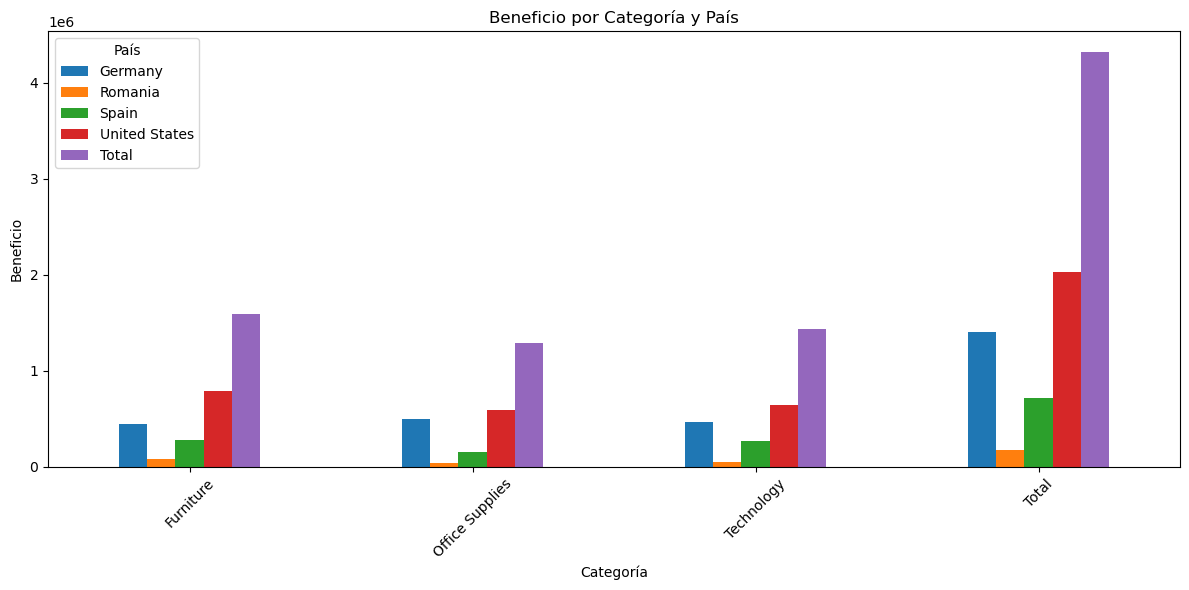

In [351]:
import seaborn as sns
import matplotlib.pyplot as plt
Beneficios_cat_pais.plot(
    kind='bar',
    figsize=(12, 6),
    title='Beneficio por Categoría y País'
)
plt.ylabel('Beneficio')
plt.xlabel('Categoría')
plt.xticks(rotation=45)
plt.legend(title='País')
plt.tight_layout()
plt.show()